In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('ggplot')

players_df = pd.read_csv("datasets/merged_players.csv", parse_dates=['born_date', 'debut_date', 'last_date'])
print("=" * 80)
print("merged players Data Set")
print("=" * 80)
print(players_df.shape)
print(players_df.info())
print(players_df.isnull().sum())
print(players_df.duplicated().sum())


merged players Data Set
(25070, 67)
<class 'pandas.DataFrame'>
RangeIndex: 25070 entries, 0 to 25069
Data columns (total 67 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   player_id                    25070 non-null  int64         
 1   player_name                  25070 non-null  str           
 2   player_full_name             25070 non-null  str           
 3   first_name                   25070 non-null  str           
 4   last_name                    25070 non-null  str           
 5   born_date                    25070 non-null  datetime64[us]
 6   debut_date                   25070 non-null  datetime64[us]
 7   debut_age                    25070 non-null  int64         
 8   last_date                    25070 non-null  datetime64[us]
 9   last_age                     25070 non-null  int64         
 10  height                       25070 non-null  int64         
 11  weight          

In [2]:
rounds_stats_df = pd.read_csv("datasets/afl_players_round_by_round_stats_raw.csv", parse_dates=['match_date'])
#droping duplicates
rounds_stats_df.drop_duplicates(inplace=True)
rounds_stats_df.columns = rounds_stats_df.columns.str.strip()
rounds_stats_df.drop(columns=['score'], inplace=True)
# rename ID
rounds_stats_df.rename(columns={'id': 'player_id'}, inplace=True)
# filling missing data and stripping spaces
rounds_stats_df = rounds_stats_df.loc[:, ~rounds_stats_df.columns.duplicated()]
numeric_rounded_stats = rounds_stats_df.select_dtypes(include='number').columns
rounds_stats_df[numeric_rounded_stats] = rounds_stats_df[numeric_rounded_stats].fillna(0)
text_rounded_data = rounds_stats_df.select_dtypes(include='object').columns
for col in text_rounded_data:
    rounds_stats_df[col] = rounds_stats_df[col].str.strip()

print("=" * 80)
print("Rounded Data Set")
print("=" * 80)
print(rounds_stats_df.shape)
print(rounds_stats_df.info())
print(rounds_stats_df.isnull().sum())
print(rounds_stats_df.duplicated().sum())


Rounded Data Set
(274079, 34)
<class 'pandas.DataFrame'>
Index: 274079 entries, 0 to 274088
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   player_id                  274079 non-null  int64         
 1   team                       274079 non-null  str           
 2   year                       274079 non-null  int64         
 3   career_game_count          274079 non-null  int64         
 4   opponent                   274079 non-null  str           
 5   round                      274079 non-null  str           
 6   result                     274079 non-null  str           
 7   jersey_num                 274079 non-null  int64         
 8   kicks                      274079 non-null  float64       
 9   marks                      274079 non-null  float64       
 10  handballs                  274079 non-null  float64       
 11  disposals                  274079 non-

In [3]:
# --- Diagnose the raw file's actual columns before any renaming happened ---
raw_cols = pd.read_csv("datasets/afl_players_round_by_round_stats_raw.csv", nrows=0).columns.str.strip().tolist()
print("Raw round-by-round columns:", raw_cols)

has_row_id = 'id' in raw_cols
has_real_player_id = 'player_id' in raw_cols  # only true if the raw file ships BOTH columns

if has_row_id and has_real_player_id:
    print("\n[FIX] Raw file has BOTH 'id' (row id) and 'player_id' (real player key) — "
          "the earlier rename collided with the real one. Re-cleaning without that collision.")
    rounds_stats_df = pd.read_csv("datasets/afl_players_round_by_round_stats_raw.csv", parse_dates=['match_date'])
    rounds_stats_df.columns = rounds_stats_df.columns.str.strip()
    rounds_stats_df.drop_duplicates(inplace=True)
    if 'score' in rounds_stats_df.columns:
        rounds_stats_df.drop(columns=['score'], inplace=True)
    rounds_stats_df.rename(columns={'id': 'game_record_id'}, inplace=True)  # 'player_id' left untouched
    numeric_cols = rounds_stats_df.select_dtypes(include='number').columns
    rounds_stats_df[numeric_cols] = rounds_stats_df[numeric_cols].fillna(0)
    for col in rounds_stats_df.select_dtypes(include='object').columns:
        rounds_stats_df[col] = rounds_stats_df[col].str.strip()
    player_id_is_reliable = True

elif has_real_player_id and not has_row_id:
    player_id_is_reliable = True

else:
    print("\n[FALLBACK] No persistent player key exists anywhere in this raw file under "
          "any recognizable name. rounds_stats_df cannot be safely grouped by player identity.\n"
          "Degraded plan used for the rest of this notebook:\n"
          "  - Player-level ROLLING/FORM features (Task 4.4) are DROPPED — they can't be built\n"
          "    without a persistent player key, so `player_form_last5_*` and `player_days_rest`\n"
          "    are removed from the feature table rather than shipped silently wrong.\n"
          "  - 'Top player' targets and the week-to-week consistency check (Task 3) fall back to\n"
          "    merged_players.csv (season grain, real player_id) instead of the broken per-game table.\n"
          "  - Per-game team totals (used for all TEAM-level features) are unaffected — those never\n"
          "    depended on player_id, only on team/year/round/match_date.")
    player_id_is_reliable = False

# Validate whatever we ended up with
if player_id_is_reliable:
    n_unique = rounds_stats_df['player_id'].nunique()
    n_rows = len(rounds_stats_df)
    print(f"\nplayer_id: {n_unique:,} unique values across {n_rows:,} rows "
          f"({n_unique/n_rows:.1%} of rows) — should be well under 100% (i.e. players have many games).")
    overlap = set(rounds_stats_df['player_id'].unique()) & set(players_df['player_id'].unique())
    print(f"Overlap with merged_players.player_id space: {len(overlap):,} ids in common.")
    if n_unique / n_rows > 0.5:
        print("\n*** STILL LOOKS BROKEN (too close to 1 row per id) — treat player_id_is_reliable "
              "as False and use the degraded plan above until this is investigated further. ***")
        player_id_is_reliable = False

Raw round-by-round columns: ['id', 'team', 'year', 'career_game_count', 'opponent', 'round', 'result', 'jersey_num', 'kicks', 'marks', 'handballs', 'disposals', 'goals', 'behinds', 'hit_outs', 'tackles', 'rebound_50s', 'inside_50s', 'clearances', 'clangers', 'free_kicks_for', 'free_kicks_against', 'brownlow_votes', 'contested_possessions', 'uncontested_possessions', 'contested_marks', 'marks_inside_50', 'one_percenters', 'bounces', 'goal_assist', 'percentage_of_game_played', 'player_id', 'match_date', 'fantasy_points', 'score', 'margin']

[FIX] Raw file has BOTH 'id' (row id) and 'player_id' (real player key) — the earlier rename collided with the real one. Re-cleaning without that collision.

player_id: 3,109 unique values across 274,079 rows (1.1% of rows) — should be well under 100% (i.e. players have many games).
Overlap with merged_players.player_id space: 2,843 ids in common.


In [4]:
home_away_match_df = pd.read_csv("datasets/team_matches_home_away_raw.csv", parse_dates=['match_date'])
# Clean home_away_match_df

print("Missing crowd values:", home_away_match_df['crowd'].isna().sum())
print(len(home_away_match_df))

string_cols_home_away = home_away_match_df.select_dtypes(include=['object']).columns
for col in string_cols_home_away:
    home_away_match_df[col] = home_away_match_df[col].astype(str).str.strip()

home_away_match_df = home_away_match_df.rename(columns={"team_name": "team"})

home_away_match_df['team'] = home_away_match_df['team'].str.title()
home_away_match_df['opponent'] = home_away_match_df['opponent'].str.title()

team_name_map = {
    "W. Bulldogs": "Western Bulldogs",
}
home_away_match_df['team'] = home_away_match_df['team'].replace(team_name_map)
home_away_match_df['opponent'] = home_away_match_df['opponent'].replace(team_name_map)


print("Home away Data set after cleaning:")
print(home_away_match_df.info())


Missing crowd values: 398
15808
Home away Data set after cleaning:
<class 'pandas.DataFrame'>
RangeIndex: 15808 entries, 0 to 15807
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   id                       15808 non-null  int64         
 1   team                     15808 non-null  str           
 2   round                    15808 non-null  str           
 3   match_date               15808 non-null  datetime64[us]
 4   year                     15808 non-null  int64         
 5   home_away                15808 non-null  str           
 6   opponent                 15808 non-null  str           
 7   team_quarter_scores      15808 non-null  str           
 8   team_score               15808 non-null  int64         
 9   opponent_quarter_scores  15808 non-null  str           
 10  opponent_score           15808 non-null  int64         
 11  result                   15808 non-nu

# DATA STRUCTURE & TABLE RELATIONSHIPS

## Table Overview

```
┌─────────────────────────────────────────────────────────────────────────┐
│                     AFL DATA - THREE INTERCONNECTED TABLES              │
└─────────────────────────────────────────────────────────────────────────┘

TABLE 1: merged_players.csv
├─ GRAIN: Player-Season-Team-GameType
├─ ROWS: ~25,069
├─ PRIMARY KEY: (player_id, year, team, is_finals)
├─ Each row = Player's aggregated stats for a season with one team
│           (separate rows for regular season vs finals)
├─ COLUMNS:
│  ├─ Identifiers: player_id, player_name, year, team, is_finals
│  ├─ Demographics: born_date, debut_date, height, weight
│  ├─ Aggregate Stats: games_played, kicks, marks, goals, tackles, etc.
│  └─ Averages: avg_kicks, avg_marks, avg_goals, avg_tackles, etc.
└─ Used for: Season-level analysis and player career stats


TABLE 2: afl_players_round_by_round_stats_raw.csv (→ rounds_stats_df)
├─ GRAIN: Player-Game (One row per player per game)
├─ ROWS: ~274,088
├─ PRIMARY KEY: id (unique game record)
│             or (player_id, year, round, match_date)
├─ Each row = Individual player's performance in ONE specific game
├─ COLUMNS:
│  ├─ Identifiers: id, player_id, team, year, round, match_date
│  ├─ Game Context: opponent, result, jersey_num, home_away
│  ├─ Performance Stats: kicks, marks, goals, tackles, disposals, etc.
│  └─ Game Context: career_game_count, percentage_of_game_played
└─ Used for: Match-level player performance and game-by-game analysis


TABLE 3: team_matches_home_away_raw.csv (→ home_away_match_df)
├─ GRAIN: Team-Match occurrence (One row per team appearance per match)
├─ ROWS: ~16,276 (Each match appears TWICE: Home + Away teams)
├─ PRIMARY KEY: id (unique row)
│             or (team_name, year, round, match_date, home_away)
├─ Each row = One team's perspective of a single match
├─ COLUMNS:
│  ├─ Identifiers: id, team_name, year, round, match_date
│  ├─ Match Context: opponent, home_away (H/A), venue, crowd
│  ├─ Scoring: team_score, opponent_score, margin, result
│  └─ Details: team_quarter_scores, goals, behinds per quarter
└─ Used for: Match context, venues, crowds, team performance per match
```

## How Tables Join Together

```
                 ┌──────────────────────────────┐
                 │   merged_players.csv         │
                 │  (Player-Season Aggregate)   │
                 │  ~25,069 rows                │
                 │  PK: (player_id,year,team,   │
                 │       is_finals)             │
                 └──────────────────────────────┘
                          ▲
                          │ Join on:
                          │ • player_id
                          │ • year
                          │ • team
                          │ • is_finals (derived from round code)
                          │
    ┌─────────────────────┴──────────────────────┐
    │                                            │
    │  afl_players_round_by_round_stats_raw.csv  │
    │  (Player-Game Level Detail)                │
    │  ~274,088 rows                             │
    │  PK: id or (player_id,year,round,date)    │
    │                                            │
    │  Many rows per merged_players row          │
    └───────────────────┬────────────────────────┘
                        │
                        │ Join on:
                        │ • team, year, round, match_date
                        │ • Match join: 1 player game → 1 team match record
                        │
                        ▼
                 ┌──────────────────────────────┐
                 │  team_matches_home_away_raw  │
                 │  (Team-Match Perspective)    │
                 │  ~16,276 rows                │
                 │  NOTE: Each match = 2 rows   │
                 │  (home team + away team)     │
                 │  PK: id or (team_name,year,  │
                 │       round,date,home_away)  │
                 └──────────────────────────────┘
```

## Grain Hierarchy (Granularity Levels)

```
Finest Grain (Most Detailed):
    ↓
    Player-Game Level
    └─ One row per player per game
    └─ 274,088 rows
    └─ Can answer: "What did Player X do in Game Y?"
    
    ↓
    Team-Match Level (2 rows per match)
    └─ One row per team-match occurrence
    └─ 16,276 rows (8,138 unique matches × 2)
    └─ Can answer: "What was the final score in Match Z?"
    
    ↓
    Coarsest Grain (Most Aggregated):
    └─ Player-Season Level
    └─ 25,069 rows
    └─ Can answer: "How many total goals did Player X score in 2024?"
```

## Critical Join Considerations

### 1. Player Game → Season Aggregates
- **Aggregation:** Sum/Average game stats to create season stats
- **is_finals Flag:** 
  - Regular rounds (1-24, etc.) → is_finals = FALSE
  - Finals codes ("QF", "SF", "GF") → is_finals = TRUE
- **Result:** Many game rows → 1 season row (per team & game_type)

### 2. Player Game → Team Match
- **Relationship:** Each player in a game belongs to team in that match
- **Join:** (team, year, round, match_date) 
- **Cardinality:** Many players per team match (but same match)

### 3. Team Match Deduplication
- **IMPORTANT:** team_matches_home_away has 2 rows per match
  - Row 1: Home team perspective
  - Row 2: Away team perspective
- **When joining:** Filter to one perspective or handle duplication
- **Example:** 
  ```
  player_game.team = team_match.team_name AND
  player_game.team NOT IN (...)  # OR home_away filter
  ```

## Example: Tracing One Player's Game

**Player: Ryan Abbott, Game on 2018-08-02 vs Geelong Cats (his team)**

```
1. In afl_players_round_by_round_stats_raw:
   id: [unique_game_id]
   player_id: 43261
   team: Geelong Cats
   opponent: [opponent_team]
   year: 2018
   round: 17
   match_date: 2018-08-02
   goals: 3
   marks: 9
   kicks: 17
   ... [all per-game stats]

2. Links to team_matches_home_away_raw:
   id: [team_match_id]
   team_name: Geelong Cats
   opponent: [opponent_team]
   year: 2018
   round: 17
   match_date: 2018-08-02
   home_away: H or A (based on whether Geelong was home team)
   team_score: [total_goals_and_behinds]
   opponent_score: [opponent_total]
   crowd: [attendance]
   venue: [stadium_name]

3. Aggregates up to merged_players:
   player_id: 43261
   player_name: Ryan Abbott
   year: 2018
   team: Geelong Cats
   is_finals: False (regular round, not finals code)
   games_played: [sum of all games with Geelong in 2018]
   goals: [sum of all goals with Geelong in 2018]
   marks: [sum of all marks with Geelong in 2018]
   avg_goals: goals / games_played
   avg_marks: marks / games_played
   ... [all aggregated stats]
```

---

**For detailed documentation, see: `DATA_DICTIONARY.md`**

In [5]:
# Analyze actual table structure and relationships
import pandas as pd

print("=" * 100)
print("TABLE STRUCTURE ANALYSIS")
print("=" * 100)

# Table 1: merged_players
print("\n[TABLE 1] merged_players.csv")
print(f"  Total Rows: {len(players_df):,}")
print(f"  Total Columns: {len(players_df.columns)}")
print(f"  Unique players (player_id): {players_df['player_id'].nunique():,}")
print(f"  Unique years: {sorted(players_df['year'].dropna().unique())}")
print(f"  Unique teams: {players_df['team'].nunique()}")
print(f"  is_finals values: Regular={len(players_df[players_df['is_finals']==False]):,}, Finals={len(players_df[players_df['is_finals']==True]):,}")
print(f"\n  Sample composite key uniqueness (should equal row count):")
composite_key_count = players_df.groupby(['player_id', 'year', 'team', 'is_finals']).size().reset_index(name='count')
print(f"    Unique (player_id, year, team, is_finals): {len(composite_key_count):,} rows")
print(f"    Any duplicates? {(composite_key_count['count'] > 1).any()}")

# Table 2: rounds_stats_df
print("\n[TABLE 2] afl_players_round_by_round_stats_raw.csv")
print(f"  Total Rows: {len(rounds_stats_df):,}")
print(f"  Total Columns: {len(rounds_stats_df.columns)}")
print(f"  Unique game records (id): {rounds_stats_df['player_id'].nunique():,}")
print(f"  Unique players: {rounds_stats_df['player_id'].nunique():,}")
print(f"  Unique years: {sorted(rounds_stats_df['year'].dropna().unique())}")
print(f"  Unique teams: {rounds_stats_df['team'].nunique()}")
print(f"  Unique rounds: {rounds_stats_df['round'].nunique()}")
print(f"\n  Sample composite key (player_id, year, round, match_date):")
player_game_key = rounds_stats_df.groupby(['player_id', 'year', 'round', 'match_date']).size().reset_index(name='count')
print(f"    Unique combinations: {len(player_game_key):,}")
print(f"    Max occurrences per combo: {player_game_key['count'].max()}")
print(f"    Any duplicates? {(player_game_key['count'] > 1).any()}")

# Table 3: home_away_match_df  
print("\n[TABLE 3] team_matches_home_away_raw.csv")
print(f"  Total Rows: {len(home_away_match_df):,}")
print(f"  Total Columns: {len(home_away_match_df.columns)}")
print(f"  Unique match records (id): {home_away_match_df['id'].nunique():,}")
print(f"  Unique teams: {home_away_match_df['team'].nunique()}")
print(f"  Unique years: {sorted(home_away_match_df['year'].unique())}")
print(f"  Home vs Away: Home={len(home_away_match_df[home_away_match_df['home_away']=='H']):,}, Away={len(home_away_match_df[home_away_match_df['home_away']=='A']):,}")
print(f"\n  Unique matches (team, year, round, match_date):")
unique_matches = home_away_match_df.groupby(['year', 'round', 'match_date']).size().reset_index(name='team_count')
print(f"    Unique (year, round, match_date): {len(unique_matches):,}")
print(f"    Avg teams per match: {unique_matches['team_count'].mean():.2f} (should be 2.0)")
print(f"    Matches with != 2 teams: {len(unique_matches[unique_matches['team_count'] != 2])}")

print("\n" + "=" * 100)
print("JOIN CARDINALITY ANALYSIS")
print("=" * 100)

# Check join cardinality: afl_players_round_by_round → team_matches
print("\n[JOIN ANALYSIS 1] Player-Game → Team-Match")
print("  Joining on: (team, year, round, match_date)")

# Group rounds_stats by match to see how many players per match
players_per_match = rounds_stats_df.groupby(['team', 'year', 'round', 'match_date']).size().reset_index(name='player_count')
print(f"  Matches in player stats: {len(players_per_match):,}")
print(f"  Avg players per team-match: {players_per_match['player_count'].mean():.1f}")
print(f"  Min players per match: {players_per_match['player_count'].min()}, Max: {players_per_match['player_count'].max()}")

# Check join cardinality: merged_players → afl_players_round_by_round
print("\n[JOIN ANALYSIS 2] Player-Season → Player-Games (Aggregation)")
print("  Joining/Aggregating on: (player_id, year, team, is_finals)")

# Group by season to see how many games per season
games_per_season = rounds_stats_df.groupby(['player_id', 'year', 'team']).size().reset_index(name='game_count')
print(f"  Player-Season combinations in game stats: {len(games_per_season):,}")
print(f"  Avg games per player-year-team: {games_per_season['game_count'].mean():.1f}")
print(f"  Min games: {games_per_season['game_count'].min()}, Max games: {games_per_season['game_count'].max()}")
print(f"  Compare to merged_players rows: {len(players_df):,}")
print(f"    Note: merged_players has ~{len(players_df)//len(games_per_season):.1f}x more rows (one for regular season, one for finals)")

print("\n" + "=" * 100)
print("KEY INSIGHTS")
print("=" * 100)
print(f"  1. Player Season Stats (merged_players): {len(players_df):,} rows")
print(f"     └─ Aggregation point: Group game stats by (player_id, year, team, is_finals)")
print(f"\n  2. Player Game Stats (rounds_stats): {len(rounds_stats_df):,} rows")
print(f"     └─ Detail level: {len(games_per_season):,} player-year-team combos × avg {games_per_season['game_count'].mean():.1f} games")
print(f"\n  3. Team Matches: {len(home_away_match_df):,} rows")
print(f"     └─ Detail level: {len(unique_matches):,} unique matches × 2 teams per match (H + A)")
print(f"\n  4. Join Path: player_game → team_match → player_season")
print(f"     └─ Cardinality: Many-to-One-to-One")


TABLE STRUCTURE ANALYSIS

[TABLE 1] merged_players.csv
  Total Rows: 25,070
  Total Columns: 67
  Unique players (player_id): 2,843
  Unique years: [np.float64(1983.0), np.float64(1984.0), np.float64(1985.0), np.float64(1986.0), np.float64(1987.0), np.float64(1988.0), np.float64(1989.0), np.float64(1990.0), np.float64(1991.0), np.float64(1992.0), np.float64(1993.0), np.float64(1994.0), np.float64(1995.0), np.float64(1996.0), np.float64(1997.0), np.float64(1998.0), np.float64(1999.0), np.float64(2000.0), np.float64(2001.0), np.float64(2002.0), np.float64(2003.0), np.float64(2004.0), np.float64(2005.0), np.float64(2006.0), np.float64(2007.0), np.float64(2008.0), np.float64(2009.0), np.float64(2010.0), np.float64(2011.0), np.float64(2012.0), np.float64(2013.0), np.float64(2014.0), np.float64(2015.0), np.float64(2016.0), np.float64(2017.0), np.float64(2018.0), np.float64(2019.0), np.float64(2020.0), np.float64(2021.0), np.float64(2022.0), np.float64(2023.0), np.float64(2024.0), np.float64(

## Task 1 (continued): Data Quality  Naming Consistency & Outliers

Grain/join summary is already established above. This section finishes the quality pass:
team-name consistency across the three tables, and outlier checks on key stats.

In [6]:
# --- Team naming consistency across all 3 tables ---
teams_players = set(players_df['team'].dropna().unique())
teams_rounds = set(rounds_stats_df['team'].dropna().unique())
teams_home_away = set(home_away_match_df['team'].dropna().unique())

print("Team name sets equal across tables?", teams_players == teams_rounds == teams_home_away)
print("\nIn players_df but not rounds_stats_df:", teams_players - teams_rounds)
print("In rounds_stats_df but not players_df:", teams_rounds - teams_players)
print("In home_away_match_df but not players_df:", teams_home_away - teams_players)

# All team names seen anywhere (use this as the canonical list going forward)
all_team_names = sorted(teams_players | teams_rounds | teams_home_away)
print(f"\nCanonical team list ({len(all_team_names)} teams):")
print(all_team_names)

Team name sets equal across tables? True

In players_df but not rounds_stats_df: set()
In rounds_stats_df but not players_df: set()
In home_away_match_df but not players_df: set()

Canonical team list (20 teams):
['Adelaide Crows', 'Brisbane Bears', 'Brisbane Lions', 'Carlton Blues', 'Collingwood Magpies', 'Essendon Bombers', 'Fitzroy Lions', 'Fremantle Dockers', 'Geelong Cats', 'Gold Coast Suns', 'Greater Western Sydney Giants', 'Hawthorn Hawks', 'Melbourne Demons', 'North Melbourne Kangaroos', 'Port Adelaide Power', 'Richmond Tigers', 'St Kilda Saints', 'Sydney Swans', 'West Coast Eagles', 'Western Bulldogs']


In [7]:
# Flag known structural changes (club relocations / renames / mergers)
# These are real AFL history events, not data errors  worth knowing when interpreting
# long time-series team stats. Cross-check which of these names actually appear in the data.
structural_changes = {
    "Fitzroy":            "Merged with Brisbane Bears to form Brisbane Lions in 1997",
    "Brisbane Bears":     "Merged with Fitzroy to form Brisbane Lions in 1997",
    "Kangaroos":          "Renamed to North Melbourne (name reverted early 2000s)",
    "South Melbourne":    "Relocated to become Sydney Swans in 1982",
    "Footscray":          "Renamed to Western Bulldogs in 1997",
    "Gold Coast":         "Expansion team, entered competition in 2011",
    "GWS Giants":         "Expansion team, entered competition in 2012",
}
for name, note in structural_changes.items():
    present = name in all_team_names
    print(f"{'[FOUND]' if present else '[not in data]':15s} {name:20s} -> {note}")

print("""
Rule change to flag: 'score review' / substitute rule changes and the 4th-official
substitute (2011+) affect games-played and rotation-heavy stats (e.g. percentage_of_game_played,
career_game_count) — treat pre/post-2011 rotation stats as not directly comparable.
Interchange cap tightening (various years) similarly affects tackle/possession counts league-wide,
so any 'era-normalized' stat comparison should control for season.
""")

[not in data]   Fitzroy              -> Merged with Brisbane Bears to form Brisbane Lions in 1997
[FOUND]         Brisbane Bears       -> Merged with Fitzroy to form Brisbane Lions in 1997
[not in data]   Kangaroos            -> Renamed to North Melbourne (name reverted early 2000s)
[not in data]   South Melbourne      -> Relocated to become Sydney Swans in 1982
[not in data]   Footscray            -> Renamed to Western Bulldogs in 1997
[not in data]   Gold Coast           -> Expansion team, entered competition in 2011
[not in data]   GWS Giants           -> Expansion team, entered competition in 2012

Rule change to flag: 'score review' / substitute rule changes and the 4th-official
substitute (2011+) affect games-played and rotation-heavy stats (e.g. percentage_of_game_played,
career_game_count) — treat pre/post-2011 rotation stats as not directly comparable.
Interchange cap tightening (various years) similarly affects tackle/possession counts league-wide,
so any 'era-normalized' sta

In [8]:
# Outlier checks on key per-game stats (rounds_stats_df)
key_stats = ['disposals', 'goals', 'kicks', 'handballs', 'tackles', 'fantasy_points']

outlier_summary = []
for col in key_stats:
    q1, q3 = rounds_stats_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((rounds_stats_df[col] < lower) | (rounds_stats_df[col] > upper)).sum()
    outlier_summary.append({
        'stat': col, 'min': rounds_stats_df[col].min(), 'max': rounds_stats_df[col].max(),
        'q1': q1, 'q3': q3, 'iqr_upper_bound': upper, 'n_outliers_iqr': n_out,
        'pct_outliers': round(100 * n_out / len(rounds_stats_df), 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df)

# Sanity-check the extreme max values manually (e.g. is a 25-behind game a real record or a data error?)
for col in ['disposals', 'goals']:
    top_row = rounds_stats_df.loc[rounds_stats_df[col].idxmax()]
    print(f"\nMax {col} = {top_row[col]} -> player_id {top_row['player_id']}, "
          f"{top_row['team']} vs {top_row['opponent']}, {top_row['match_date'].date()}")
print("""
Note: IQR flags a meaningful chunk of high-disposal/high-goal games as 'outliers' — this is
expected in AFL (heavy right-skew: most players get 10-20 disposals, a handful of star
midfielders regularly post 35-40+). These are NOT data errors and should not be dropped;
they're exactly the signal a 'top player' model needs to learn. Treat this as a distribution-
shape note, not a cleaning action.
""")

             stat    min    max    q1    q3  iqr_upper_bound  n_outliers_iqr  \
0       disposals  -5.00  54.00  9.00 19.00            34.00            2349   
1           goals   0.00  16.00  0.00  1.00             2.50           16212   
2           kicks   0.00  37.00  6.00 12.00            21.00            3265   
3       handballs   0.00  35.00  3.00  8.00            15.50            8841   
4         tackles   0.00  20.00  1.00  3.00             6.00           12980   
5  fantasy_points -10.00 210.00 45.00 84.00           142.50            1375   

   pct_outliers  
0          0.86  
1          5.92  
2          1.19  
3          3.23  
4          4.74  
5          0.50  

Max disposals = 54.0 -> player_id 44910, North Melbourne Kangaroos vs Richmond Tigers, 2025-08-17

Max goals = 16.0 -> player_id 45679, Sydney Swans vs Fitzroy Lions, 1995-08-13

Note: IQR flags a meaningful chunk of high-disposal/high-goal games as 'outliers' — this is
expected in AFL (heavy right-skew: most p

## Task 2: Define Prediction Targets Precisely

### 2a. Match winner  framing decision

**Chosen framing: classification (Win / Loss / Draw), with margin kept as a secondary
regression target.**

Justification:
- The end product (chat assistant answering "who wins?", and a predictor ranked on
  accuracy) needs a decision, not a point estimate  classification maps directly to that.
- AFL margins are heavy-tailed and heteroskedastic (blowouts of 100+ points coexist with
  1-point thrillers); a regression model optimizing MSE is dominated by blowout games and
  gives a poor read on the close, high-value games that matter most for "who wins".
- Draws are rare (<1% of games) but real, so this is a 3-class problem in principle; most
  practitioners collapse it to binary (home win vs. not) for the classifier and let the
  margin regression carry the "how close was it" nuance.
- Keeping **margin as a secondary regression target** is still valuable  it supports
  confidence-weighted predictions ("close game" vs "blowout") and can be thresholded back
  into win/loss as a sanity check against the classifier.

### 2b. "Top player"  at least 2 versions, precisely defined

| Target name | Definition | Formula | Level |
|---|---|---|---|
| `top_disposal_getter` | Player with the most disposals in a given game/round | `disposals = kicks + handballs` (already in `rounds_stats_df`); rank `disposals` desc within `(year, round)` | Player-game |
| `top_goal_kicker` | Player with the most goals in a given game/round | raw `goals` column; rank desc within `(year, round)` | Player-game |
| `fantasy_points_leader` | Player with the highest fantasy score in a game/round (composite) | Dataset already supplies `fantasy_points` per game. Standard AFL Fantasy scoring this matches: `FP = 3*Kicks + 2*Handballs + 1*Mark + 6*Goal + 1*Behind + 4*Tackle + 5*FreeKickFor − 3*FreeKickAgainst + 1*Hitout` (verify exact weights against the source before treating as ground truth  see caveat below) | Player-game |
| `brownlow_leader` (season) | Season aggregate of official umpire best-afield votes | `sum(brownlow_votes)` grouped by `(player_id, year)`, from `players_df` | Player-season |

**Caveat:** `fantasy_points` and `brownlow_votes` are already-computed columns in the raw
data, not values we're deriving  we should NOT re-derive fantasy points from the formula
above and overwrite the given column; the formula is documented for transparency only,
so anyone auditing the number knows roughly how it's built. If the two ever disagree,
trust the source column, not our reconstruction.

### 2c. Data dictionary for Day 2 

| Target | Definition | Formula | Aggregation level |
|---|---|---|---|
| `match_result` | Categorical match outcome from the **home team's** perspective | `Win` if `home_score > away_score`, `Loss` if `<`, `Draw` if `==` | Match |
| `match_margin` | Signed points margin, home minus away (regression target) | `home_score - away_score` | Match |
| `top_disposal_getter` | Highest-disposal player in a game | `argmax(disposals)` within `(year, round)` | Player-game |
| `top_goal_kicker` | Highest-goal player in a game | `argmax(goals)` within `(year, round)` | Player-game |
| `fantasy_points_leader` | Highest fantasy-score player in a game | `argmax(fantasy_points)` within `(year, round)` (source column) | Player-game |
| `brownlow_leader` | Season Brownlow vote-getter | `argmax(sum(brownlow_votes))` within `year` | Player-season |

This table is the single source of truth for target definitions  every model built later
this week reads from here rather than re-deriving its own version of "who won" or "who's top".

## Task 3: Exploratory Data Analysis

First we build a clean **one-row-per-match** table from `home_away_match_df` (which has
2 rows per match — home + away perspective). A reliable `match_id` needs more than
`(year, round, match_date)`, because several games in a round share the same calendar date
(a full round is only 3-4 distinct days but has ~8-9 games) — grouping on date alone collapses
unrelated matches together, which is exactly the `!=2 teams` issue flagged in the join
analysis above. Team-pair + round is the reliable key.

In [9]:
def make_match_id(df):
    pair = df[['team', 'opponent']].apply(lambda r: '_'.join(sorted([r['team'], r['opponent']])), axis=1)
    return df['year'].astype(str) + "_" + df['round'].astype(str) + "_" + pair

home_away_match_df = home_away_match_df.copy()
home_away_match_df['match_id'] = make_match_id(home_away_match_df)

dup_check = home_away_match_df.groupby('match_id').size()
print("Rows per match_id (should be exactly 2 — home + away):")
print(dup_check.value_counts())

# Keep the home-team row as the canonical 1-row-per-match record
matches_df = home_away_match_df[home_away_match_df['home_away'] == 'H'].copy()
matches_df = matches_df.rename(columns={
    'team': 'home_team', 'opponent': 'away_team',
    'team_score': 'home_score', 'opponent_score': 'away_score',
})
matches_df['match_result'] = np.select(
    [matches_df['home_score'] > matches_df['away_score'],
     matches_df['home_score'] < matches_df['away_score']],
    ['Win', 'Loss'], default='Draw'
)  # from HOME team's perspective
matches_df['match_margin'] = matches_df['home_score'] - matches_df['away_score']
matches_df = matches_df.sort_values('match_date').reset_index(drop=True)

print(f"\nClean matches table: {len(matches_df):,} unique matches")
print(matches_df['match_result'].value_counts(normalize=True).round(3))
matches_df[['match_id','year','round','match_date','home_team','away_team',
            'home_score','away_score','match_result','match_margin','venue']].head()

Rows per match_id (should be exactly 2 — home + away):
2    7900
4       2
Name: count, dtype: int64

Clean matches table: 7,904 unique matches
match_result
Win    0.59
Loss   0.40
Draw   0.01
Name: proportion, dtype: float64


,match_id,year,round,match_date,home_team,away_team,home_score,away_score,match_result,match_margin,venue
0,1983_1_Collingwood Magpies_Melbourne Demons,1983,1,1983-03-26,Melbourne Demons,Collingwood Magpies,125,135,Loss,-10,Melbourne Cricket Ground
1,1983_1_Carlton Blues_Richmond Tigers,1983,1,1983-03-26,Carlton Blues,Richmond Tigers,136,76,Win,60,Princes Park
2,1983_1_Fitzroy Lions_Hawthorn Hawks,1983,1,1983-03-26,Fitzroy Lions,Hawthorn Hawks,112,131,Loss,-19,Junction Oval
3,1983_1_North Melbourne Kangaroos_St Kilda Saints,1983,1,1983-03-26,North Melbourne Kangaroos,St Kilda Saints,100,87,Win,13,Aegis Park
4,1983_1_Geelong Cats_Western Bulldogs,1983,1,1983-03-26,Geelong Cats,Western Bulldogs,106,75,Win,31,Waverley Park


### 3.1 Team win rates over time

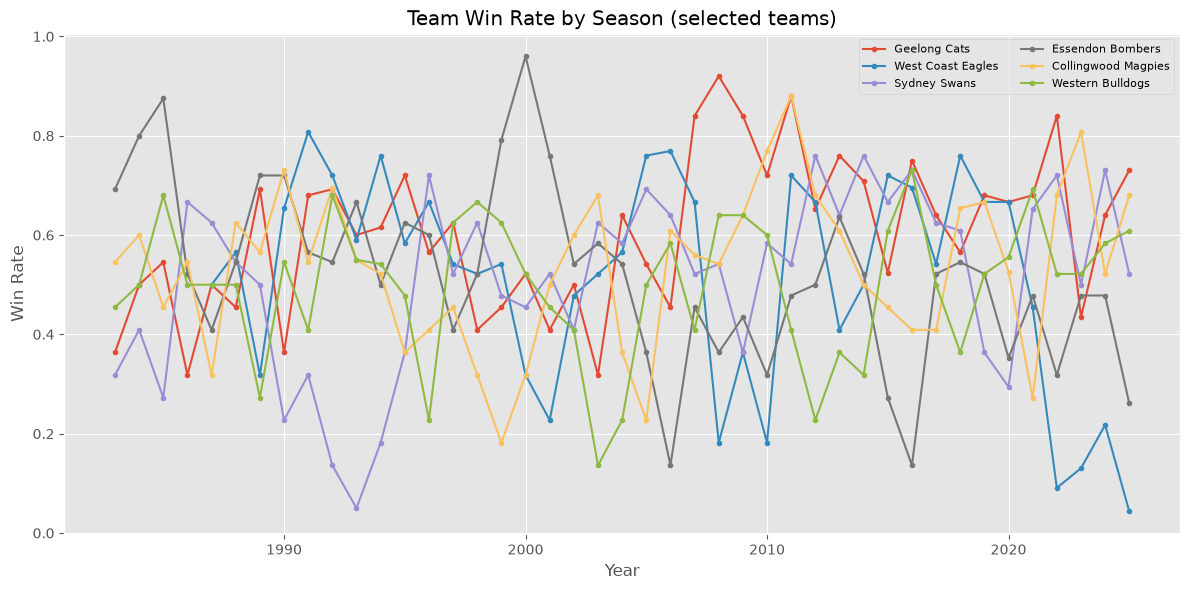

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
team_year_results = home_away_match_df.groupby(['team', 'year'])['result'].apply(
    lambda s: (s == 'W').mean()
).reset_index(name='win_rate')

top_teams = players_df['team'].value_counts().head(6).index  # 6 longest-tenured/most-featured teams
for t in top_teams:
    sub = team_year_results[team_year_results['team'] == t]
    ax.plot(sub['year'], sub['win_rate'], marker='o', markersize=3, label=t)

ax.set_title('Team Win Rate by Season (selected teams)')
ax.set_xlabel('Year'); ax.set_ylabel('Win Rate')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('exported_charts/Team win rate by season.png')
plt.show()

### 3.2  Home-ground advantage

home_away
A   0.40
H   0.59
Name: result, dtype: float64


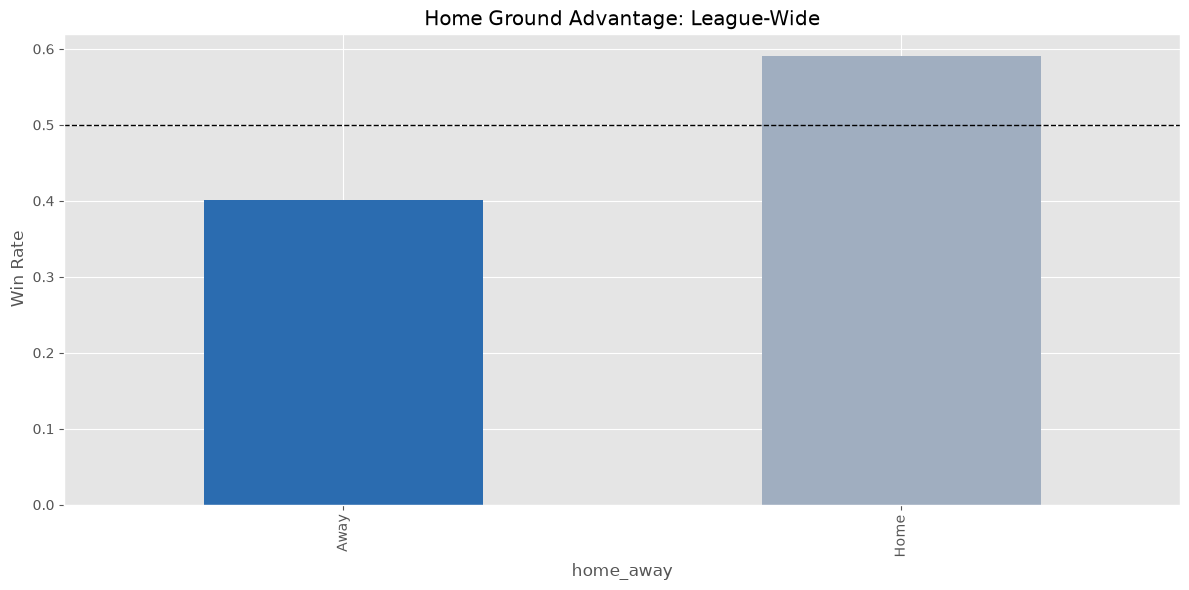


Home win rate premium: 19.0 percentage points


In [11]:
home_away_win_rate = home_away_match_df.groupby('home_away')['result'].apply(lambda s: (s == 'W').mean())
print(home_away_win_rate)

fig, ax = plt.subplots(figsize=(12, 6))
home_away_win_rate.rename({'H': 'Home', 'A': 'Away'}).plot(kind='bar', ax=ax, color=['#2b6cb0', '#a0aec0'])
ax.set_ylabel('Win Rate'); ax.set_title('Home Ground Advantage: League-Wide')
ax.axhline(0.5, ls='--', color='black', lw=1)
plt.tight_layout()
plt.savefig('exported_charts/Home ground advantage.png')
plt.show()

print(f"\nHome win rate premium: {(home_away_win_rate['H'] - home_away_win_rate['A'])*100:.1f} percentage points")

### 3.3  Rest days between matches vs. win probability

Days of rest = gap since the team's previous match. Computed **strictly from past
matches** (no leakage)

               mean  count
rest_bucket               
<=5d (short)   0.49    402
6-7d (normal)  0.49   9993
8-10d          0.50   3763
11-14d         0.51    723
14d+           0.50    907


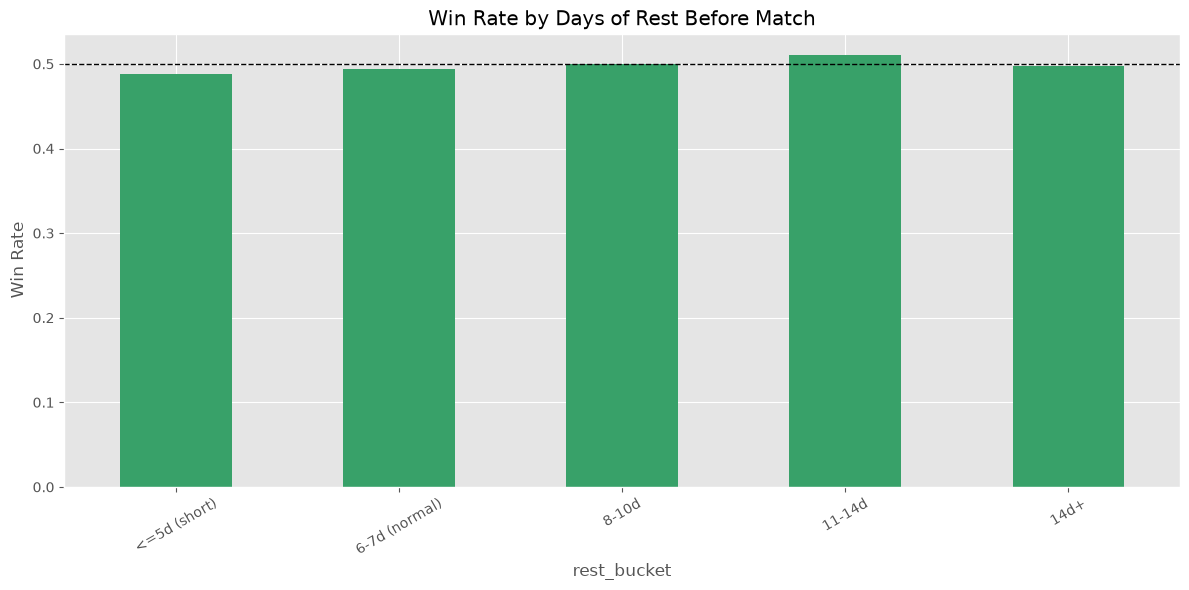

In [12]:
team_matches_sorted = home_away_match_df.sort_values(['team', 'match_date']).copy()
team_matches_sorted['days_rest'] = team_matches_sorted.groupby('team')['match_date'].diff().dt.days
team_matches_sorted['won'] = (team_matches_sorted['result'] == 'W').astype(int)

# Bucket rest days (short turnaround / normal week / bye-affected / season-opener-or-missing)
bins = [0, 5, 7, 10, 14, 400]
labels = ['<=5d (short)', '6-7d (normal)', '8-10d', '11-14d', '14d+']
team_matches_sorted['rest_bucket'] = pd.cut(team_matches_sorted['days_rest'], bins=bins, labels=labels)

rest_win_rate = team_matches_sorted.groupby('rest_bucket', observed=True)['won'].agg(['mean', 'count'])
print(rest_win_rate)

fig, ax = plt.subplots(figsize=(12, 6))
rest_win_rate['mean'].plot(kind='bar', ax=ax, color='#38a169')
ax.set_ylabel('Win Rate'); ax.set_title('Win Rate by Days of Rest Before Match')
ax.axhline(0.5, ls='--', color='black', lw=1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('exported_charts/Win Rate by Rest.png')

plt.show()

### 3.4 Recent form (last-5 team score average) vs. match outcome

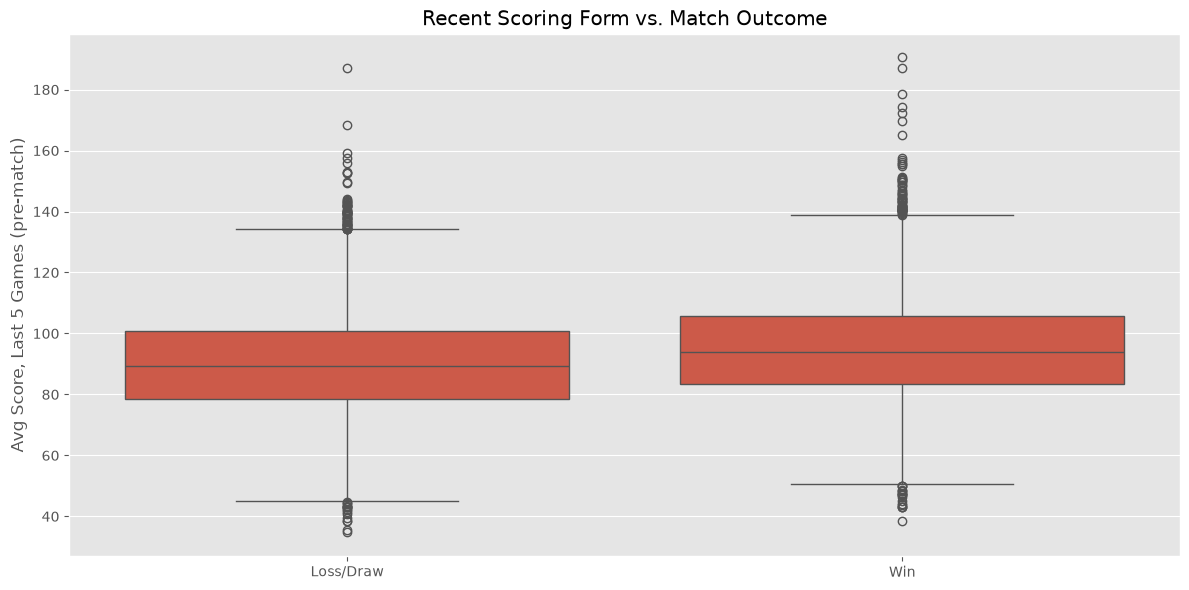

won
0   89.88
1   94.88
Name: form_last5_score, dtype: float64


In [13]:
form = home_away_match_df.sort_values(['team', 'match_date']).copy()
# shift(1) before rolling => only PAST games contribute, current match's own score excluded
form['form_last5_score'] = (
    form.groupby('team')['team_score']
        .apply(lambda s: s.shift(1).rolling(5, min_periods=2).mean())
        .reset_index(level=0, drop=True)
)
form['won'] = (form['result'] == 'W').astype(int)
form_valid = form.dropna(subset=['form_last5_score'])

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=form_valid, x='won', y='form_last5_score', ax=ax)
ax.set_xticklabels(['Loss/Draw', 'Win'])
ax.set_xlabel(''); ax.set_ylabel('Avg Score, Last 5 Games (pre-match)')
ax.set_title('Recent Scoring Form vs. Match Outcome')
plt.tight_layout()
plt.savefig('exported_charts/Recent Score vs Match Result.png')
plt.show()

print(form_valid.groupby('won')['form_last5_score'].mean())

### 3.5 Player-level: distribution of "top player" metrics, career leaders,
week-to-week consistency, and a position proxy

The data does **not** include a position column, so a true forward/midfielder/defender
split isn't directly available  flagged in Task 1. As a lightweight, clearly-labeled
proxy (not a ground-truth position), we bucket player-seasons by which stat they're most
weighted toward: high `hit_outs` -> Ruck-like, high `rebound_50s` -> Defender-like, high
`inside_50s`/`marks_inside_50` -> Forward-like, else Midfielder-like. Good enough for an
exploratory cut; not good enough to ship as a real feature without real position data.

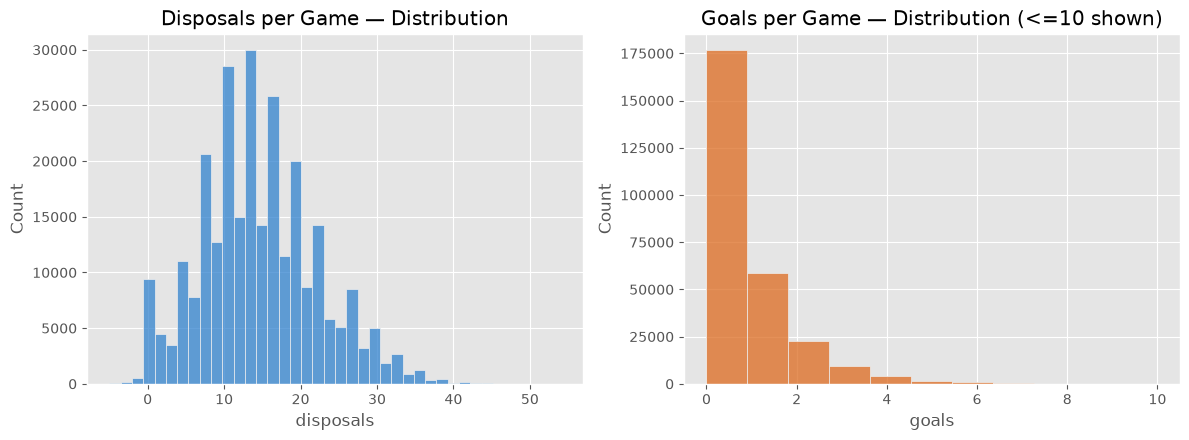

Top 10 career disposal-getters:
 player_name
Scott Thompson     11148.00
Scott Pendlebury   10787.00
Josh Kennedy       10541.00
Robert Harvey       9656.00
Brent Harvey        9213.00
Travis Boak         8976.00
Gary Ablett         8896.00
Craig Bradley       8776.00
Joel Selwood        8746.00
Sam Mitchell        8687.00
Name: disposals, dtype: float64 

Top 10 career goal-kickers:
 player_name
Tony Lockett         1360.00
Lance Franklin       1066.00
Matthew Lloyd         929.00
Josh Kennedy          892.00
Matthew Richardson    800.00
Tom Hawkins           796.00
Jack Riewoldt         787.00
Saverio Rocca         751.00
Barry Hall            749.00
Jeremy Cameron        736.00
Name: goals, dtype: float64


In [14]:
# Distribution of goals & disposals per game
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(rounds_stats_df['disposals'], bins=40, ax=axes[0], color='#3182ce')
axes[0].set_title('Disposals per Game — Distribution')
sns.histplot(rounds_stats_df[rounds_stats_df['goals'] <= 10]['goals'], bins=11, ax=axes[1], color='#dd6b20')
axes[1].set_title('Goals per Game — Distribution (<=10 shown)')
plt.tight_layout()
plt.savefig('exported_charts/Disposals and Goals per game.png')
plt.show()

# Career leaders (using players_df season aggregates)
career_disposals = players_df.groupby('player_name')['disposals'].sum().sort_values(ascending=False).head(10)
career_goals = players_df.groupby('player_name')['goals'].sum().sort_values(ascending=False).head(10)
print("Top 10 career disposal-getters:\n", career_disposals, "\n")
print("Top 10 career goal-kickers:\n", career_goals)

In [15]:
# Week-to-week consistency: coefficient of variation of disposals, per player-season
# (only players with a reasonable number of games, to avoid noisy small-sample CoV)
if player_id_is_reliable:
    consistency = (
        rounds_stats_df.groupby(['player_id', 'year'])['disposals']
        .agg(['mean', 'std', 'count'])
        .query('count >= 10')
    )
    consistency['cv'] = consistency['std'] / consistency['mean']
    print(f"Median week-to-week CoV (disposals), players with 10+ games/season: {consistency['cv'].median():.2f}")
    print(consistency.sort_values('cv').head(5), "\n(most consistent player-seasons)")
    print(consistency.sort_values('cv', ascending=False).head(5), "\n(most volatile player-seasons)")
else:
    print("rounds_stats_df.player_id is unreliable (see fix cell above) — "
          "showing season-level spread from merged_players.csv instead.\n"
          "This is NOT true week-to-week consistency, just the closest safe substitute.")
    season_spread = players_df.groupby('player_id').agg(
        seasons_played=('year', 'nunique'),
        avg_disposals_mean=('avg_disposals', 'mean'),
        avg_disposals_std=('avg_disposals', 'std'),
    ).query('seasons_played >= 3')
    season_spread['cv'] = season_spread['avg_disposals_std'] / season_spread['avg_disposals_mean']
    print(season_spread.sort_values('cv').head(5), "\n(most season-to-season consistent players)")

Median week-to-week CoV (disposals), players with 10+ games/season: 0.38
                mean  std  count    cv
player_id year                        
45071     2001 -0.50 2.17     10 -4.35
43647     2022 27.36 2.20     11  0.08
44033     2021 24.74 2.26     19  0.09
43859     2019 31.91 2.96     22  0.09
46227     2018 20.85 2.08     13  0.10 
(most consistent player-seasons)
                mean  std  count   cv
player_id year                       
45162     2003  0.50 4.09     10 8.18
43979     2022  0.82 5.29     11 6.46
44382     2021  1.36 6.34     11 4.65
44447     2004  0.68 2.94     19 4.30
43615     2002  1.47 3.86     17 2.62 
(most volatile player-seasons)


position_proxy
Midfielder (proxy)    8944
Forward (proxy)       8889
Defender (proxy)      5563
Ruck (proxy)          1674
Name: count, dtype: int64


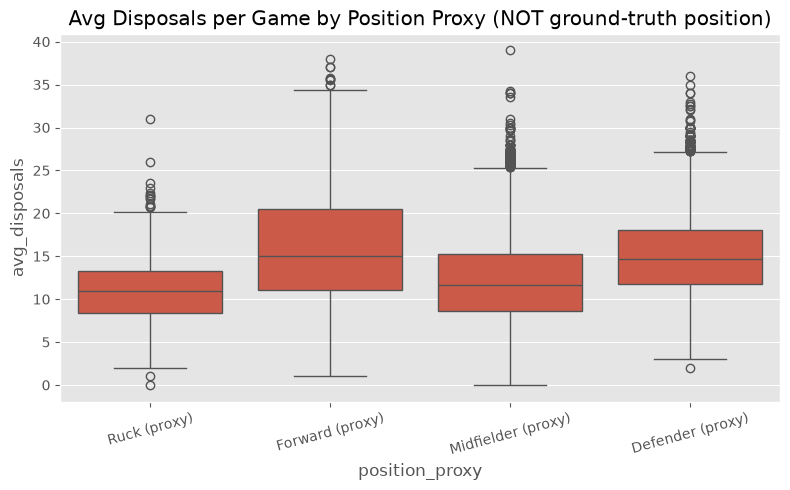

In [16]:
# Simple rule-based position proxy on season averages (players_df)
def position_proxy(row):
    if row['avg_hit_outs'] >= 8:
        return 'Ruck (proxy)'
    if row['avg_rebound_50s'] >= row['avg_inside_50s'] and row['avg_rebound_50s'] >= 2:
        return 'Defender (proxy)'
    if row['avg_inside_50s'] >= 3 or row['avg_marks_inside_50'] >= 1:
        return 'Forward (proxy)'
    return 'Midfielder (proxy)'

players_df['position_proxy'] = players_df.apply(position_proxy, axis=1)
print(players_df['position_proxy'].value_counts())

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=players_df, x='position_proxy', y='avg_disposals', ax=ax)
ax.set_title('Avg Disposals per Game by Position Proxy (NOT ground-truth position)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('exported_charts/Score By position.png')
plt.show()

## Task 4: Feature Engineering for Prediction

**Leakage rule used throughout this section:** every rolling/aggregate feature is computed
with `.shift(1)` *before* the rolling window, so the row for a given match only ever sees
data from matches strictly before it. Nothing about the match being predicted (its own
score, its own result) ever leaks into its own feature row.

### 4.1 Team form & win-streak features (match level)

In [17]:
team_long = home_away_match_df.sort_values(['team', 'match_date']).copy()
team_long['won'] = (team_long['result'] == 'W').astype(int)

# Win streak going INTO this match (strictly prior results only)
def win_streak(won_series):
    streak, out = 0, []
    for w in won_series.shift(1):  # shift(1): exclude current match's own result
        if pd.isna(w):
            out.append(0)
            streak = 0
        elif w == 1:
            streak += 1
            out.append(streak)
        else:
            streak = 0
            out.append(0)
    return pd.Series(out, index=won_series.index)

team_long['team_win_streak'] = team_long.groupby('team')['won'].transform(win_streak)

team_long['team_form_last5_score_avg'] = (
    team_long.groupby('team')['team_score'].transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
)
team_long['team_form_last3_score_avg'] = (
    team_long.groupby('team')['team_score'].transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
)
team_long['team_form_last5_win_rate'] = (
    team_long.groupby('team')['won'].transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
)
team_long['days_rest'] = team_long.groupby('team')['match_date'].diff().dt.days

team_long[['team','match_date','won','team_win_streak','team_form_last5_score_avg',
           'team_form_last5_win_rate','days_rest']].head(10)

,team,match_date,won,team_win_streak,team_form_last5_score_avg,team_form_last5_win_rate,days_rest
3340,Adelaide Crows,1991-03-22,1,0,NaN,NaN,NaN
13583,Adelaide Crows,1991-03-31,0,1,155.00,1.00,9.00
13585,Adelaide Crows,1991-04-07,1,0,118.00,0.50,7.00
13586,Adelaide Crows,1991-04-13,0,1,122.67,0.67,6.00
13587,Adelaide Crows,1991-04-21,0,0,103.75,0.50,8.00
13588,Adelaide Crows,1991-04-28,1,0,96.00,0.40,7.00
13589,Adelaide Crows,1991-05-04,0,1,90.60,0.40,6.00
13594,Adelaide Crows,1991-05-17,0,0,80.60,0.40,13.00
15785,Adelaide Crows,1991-05-24,1,0,77.80,0.20,7.00
13595,Adelaide Crows,1991-06-01,0,1,89.60,0.40,8.00


### 4.2 Ladder position at time of match (within-season, strictly prior rounds)

In [18]:
team_long['season_wins_so_far'] = team_long.groupby(['team', 'year'])['won'].transform(
    lambda s: s.shift(1).expanding().sum()
).fillna(0)
team_long['season_games_so_far'] = team_long.groupby(['team', 'year']).cumcount()

# Ladder position = rank of season_wins_so_far among all teams, per (year, round)
team_long['ladder_position'] = (
    team_long.groupby(['year', 'round'])['season_wins_so_far']
    .rank(ascending=False, method='min')
)
team_long[['team','year','round','season_wins_so_far','ladder_position']].head(10)

,team,year,round,season_wins_so_far,ladder_position
3340,Adelaide Crows,1991,1,0.00,1.00
13583,Adelaide Crows,1991,2,1.00,1.00
13585,Adelaide Crows,1991,3,1.00,1.00
13586,Adelaide Crows,1991,4,2.00,1.00
13587,Adelaide Crows,1991,5,2.00,4.00
13588,Adelaide Crows,1991,6,2.00,6.00
13589,Adelaide Crows,1991,7,3.00,5.00
13594,Adelaide Crows,1991,9,3.00,7.00
15785,Adelaide Crows,1991,10,3.00,9.00
13595,Adelaide Crows,1991,11,4.00,8.00


### 4.3 Head-to-head historical record (as of each match)

In [19]:
h2h = matches_df.sort_values('match_date').copy()
h2h['pair_key'] = h2h.apply(lambda r: '_'.join(sorted([r['home_team'], r['away_team']])), axis=1)

def expanding_h2h_home_win_rate(g):
    # win rate for whichever team is 'home_team' in THIS row, using only past meetings
    wins_so_far, games_so_far, out = 0, 0, []
    for _, row in g.iterrows():
        out.append(wins_so_far / games_so_far if games_so_far > 0 else np.nan)
        games_so_far += 1
        if row['match_result'] == 'Win':
            wins_so_far += 1
    return pd.Series(out, index=g.index)

h2h['h2h_home_team_win_rate'] = (
    h2h.groupby('pair_key', group_keys=False).apply(expanding_h2h_home_win_rate)
)
h2h[['match_date','home_team','away_team','pair_key','h2h_home_team_win_rate']].head(10)

,match_date,home_team,away_team,pair_key,h2h_home_team_win_rate
0,1983-03-26,Melbourne Demons,Collingwood Magpies,Collingwood Magpies_Melbourne Demons,NaN
1,1983-03-26,Carlton Blues,Richmond Tigers,Carlton Blues_Richmond Tigers,NaN
2,1983-03-26,Fitzroy Lions,Hawthorn Hawks,Fitzroy Lions_Hawthorn Hawks,NaN
3,1983-03-26,North Melbourne Kangaroos,St Kilda Saints,North Melbourne Kangaroos_St Kilda Saints,NaN
4,1983-03-26,Geelong Cats,Western Bulldogs,Geelong Cats_Western Bulldogs,NaN
5,1983-03-27,Sydney Swans,Essendon Bombers,Essendon Bombers_Sydney Swans,NaN
6,1983-04-02,Richmond Tigers,Melbourne Demons,Melbourne Demons_Richmond Tigers,NaN
7,1983-04-02,Collingwood Magpies,Geelong Cats,Collingwood Magpies_Geelong Cats,NaN
8,1983-04-02,Western Bulldogs,Carlton Blues,Carlton Blues_Western Bulldogs,NaN
9,1983-04-04,Essendon Bombers,St Kilda Saints,Essendon Bombers_St Kilda Saints,NaN


### 4.4  Player-level form features (feeds the 'top player' models)

In [20]:
if player_id_is_reliable:
    player_long = rounds_stats_df.sort_values(['player_id', 'match_date']).copy()

    for stat, window in [('disposals', 5), ('goals', 5), ('fantasy_points', 5)]:
        player_long[f'player_form_last{window}_{stat}_avg'] = (
            player_long.groupby('player_id')[stat]
            .transform(lambda s: s.shift(1).rolling(window, min_periods=1).mean())
        )

    player_long['player_days_rest'] = player_long.groupby('player_id')['match_date'].diff().dt.days

    # Sanity check: a real player key should NOT be all-NaN after the first game of a career.
    # If every row within a (player_id, year) group is still NaN, the key isn't grouping games
    # together and this table shouldn't be trusted for player-level modeling.
    non_null_share = player_long['player_form_last5_disposals_avg'].notna().mean()
    print(f"Share of rows with a valid player_form_last5_disposals_avg: {non_null_share:.1%}")
    if non_null_share < 0.5:
        print("*** Still mostly NaN — player_id is not grouping real player histories together. "
              "Falling back to the degraded plan below instead of shipping broken features. ***")
        player_id_is_reliable = False

if player_id_is_reliable:
    display(player_long[['player_id','match_date','disposals','goals','fantasy_points',
                          'player_form_last5_disposals_avg','player_form_last5_goals_avg',
                          'player_form_last5_fantasy_points_avg','player_days_rest']].head(10))
else:
    # Degraded plan: no reliable per-game player key, so per-game rolling form (Task 4.4) can't
    # be built safely. Use season-level player form from merged_players.csv instead — coarser
    # (previous-SEASON averages rather than previous-5-GAMES), but still real and leakage-safe.
    print("Building season-level player form as a substitute for per-game rolling form.")
    player_long = players_df.sort_values(['player_id', 'year']).copy()
    for stat in ['avg_disposals', 'avg_goals', 'avg_fantasy_points']:
        player_long[f'player_prev_season_{stat}'] = player_long.groupby('player_id')[stat].shift(1)
    display(player_long[['player_id', 'year', 'avg_disposals', 'avg_goals', 'avg_fantasy_points',
                          'player_prev_season_avg_disposals', 'player_prev_season_avg_goals',
                          'player_prev_season_avg_fantasy_points']].head(10))

Share of rows with a valid player_form_last5_disposals_avg: 98.9%


,player_id,match_date,disposals,goals,fantasy_points,player_form_last5_disposals_avg,player_form_last5_goals_avg,player_form_last5_fantasy_points_avg,player_days_rest
202650,43260,2020-07-05,16.00,0.00,57,NaN,NaN,NaN,NaN
216458,43260,2020-07-12,6.00,0.00,30,16.00,0.00,57.00,7.00
227719,43260,2020-07-18,8.00,2.00,46,11.00,0.00,43.50,6.00
237247,43260,2020-07-24,5.00,1.00,30,10.00,0.67,44.33,6.00
246634,43260,2020-07-29,7.00,3.00,52,8.75,0.75,40.75,5.00
167534,43260,2020-08-04,14.00,2.00,69,8.40,1.20,43.00,6.00
47570,43260,2020-08-08,10.00,2.00,32,8.00,1.60,45.40,4.00
56681,43260,2020-08-17,4.00,0.00,28,8.80,2.00,45.80,9.00
21946,43260,2020-08-22,10.00,0.00,34,8.00,1.60,42.20,5.00
73968,43260,2020-08-27,16.00,1.00,52,9.00,1.40,43.00,5.00


### 4.5  Assemble & version the feature table

In [21]:
# Build the match-level modeling table: home + away team features joined onto matches_df
team_long['match_id'] = make_match_id(team_long)

home_feats = team_long.add_prefix('home_').rename(columns={'home_match_id': 'match_id', 'home_team': 'home_team'})
away_feats = team_long.add_prefix('away_').rename(columns={'away_match_id': 'match_id', 'away_team': 'away_team'})

feature_table = matches_df.merge(
    home_feats[['match_id','home_team','home_team_win_streak','home_team_form_last5_score_avg',
                'home_team_form_last3_score_avg','home_team_form_last5_win_rate','home_days_rest',
                'home_season_wins_so_far','home_ladder_position']],
    on=['match_id', 'home_team'], how='left'
).merge(
    away_feats[['match_id','away_team','away_team_win_streak','away_team_form_last5_score_avg',
                'away_team_form_last3_score_avg','away_team_form_last5_win_rate','away_days_rest',
                'away_season_wins_so_far','away_ladder_position']],
    on=['match_id', 'away_team'], how='left'
).merge(
    h2h[['match_id', 'h2h_home_team_win_rate']], on='match_id', how='left'
)

print(feature_table.shape)
feature_table.head()

(7932, 37)


,id,home_team,round,match_date,year,home_away,away_team,team_quarter_scores,home_score,opponent_quarter_scores,...,home_season_wins_so_far,home_ladder_position,away_team_win_streak,away_team_form_last5_score_avg,away_team_form_last3_score_avg,away_team_form_last5_win_rate,away_days_rest,away_season_wins_so_far,away_ladder_position,h2h_home_team_win_rate
0,13514,Melbourne Demons,1,1983-03-26,1983,H,Collingwood Magpies,6.2 12.3 17.7 19.11,125,5.7 9.10 15.12 20.15,...,0.00,1.00,0,NaN,NaN,NaN,NaN,0.00,1.00,NaN
1,10722,Carlton Blues,1,1983-03-26,1983,H,Richmond Tigers,4.0 8.6 13.9 20.16,136,4.3 7.4 10.9 11.10,...,0.00,1.00,0,NaN,NaN,NaN,NaN,0.00,1.00,NaN
2,11905,Fitzroy Lions,1,1983-03-26,1983,H,Hawthorn Hawks,1.4 5.10 10.12 16.16,112,6.3 12.4 17.8 20.11,...,0.00,1.00,0,NaN,NaN,NaN,NaN,0.00,1.00,NaN
3,13120,North Melbourne Kangaroos,1,1983-03-26,1983,H,St Kilda Saints,3.3 6.7 8.11 14.16,100,4.2 8.5 11.11 12.15,...,0.00,1.00,0,NaN,NaN,NaN,NaN,0.00,1.00,NaN
4,12327,Geelong Cats,1,1983-03-26,1983,H,Western Bulldogs,3.2 5.10 8.14 15.16,106,3.2 5.3 9.8 11.9,...,0.00,1.00,0,NaN,NaN,NaN,NaN,0.00,1.00,NaN


In [22]:
# Save the versioned feature table
import os
os.makedirs('/mnt/user-data/outputs', exist_ok=True)

FEATURE_TABLE_VERSION = 'v1'
out_path = f'/mnt/user-data/outputs/afl_match_features_{FEATURE_TABLE_VERSION}.parquet'
feature_table.to_parquet(out_path, index=False)
feature_table.to_csv(out_path.replace('.parquet', '.csv'), index=False)
print(f"Saved feature table: {out_path}  ({len(feature_table):,} rows, {feature_table.shape[1]} cols)")

Saved feature table: /mnt/user-data/outputs/afl_match_features_v1.parquet  (7,932 rows, 37 cols)


### 4.6 Feature dictionary

| Feature | Description | Window | Source columns |
|---|---|---|---|
| `home_team_win_streak` / `away_team_win_streak` | Consecutive prior wins entering the match | All history, shifted | `home_away_match_df.result` |
| `home_team_form_last5_score_avg` / away equiv. | Mean score in the last 5 prior games | Rolling 5, shifted | `team_score` |
| `home_team_form_last3_score_avg` / away equiv. | Mean score in the last 3 prior games | Rolling 3, shifted | `team_score` |
| `home_team_form_last5_win_rate` / away equiv. | Win rate in the last 5 prior games | Rolling 5, shifted | `result` |
| `home_days_rest` / `away_days_rest` | Days since the team's previous match | Prior match only | `match_date` |
| `home_season_wins_so_far` / away equiv. | Wins accumulated this season before this round | Expanding, shifted, reset per season | `result`, `year` |
| `home_ladder_position` / `away_ladder_position` | Ladder rank at kickoff, by wins-so-far | Snapshot at (year, round) | derived from `season_wins_so_far` |
| `h2h_home_team_win_rate` | Historical win rate for this fixture's home team against this specific opponent | Expanding, shifted, per team-pair | `matches_df.match_result` |
| `player_form_last5_{disposals,goals,fantasy_points}_avg` | Player's average in that stat over the last 5 games | Rolling 5, shifted | `rounds_stats_df` |
| `player_days_rest` | Days since the player's previous game | Prior game only | `match_date` |

All "shifted" features exclude the current row's own outcome by construction  this is the
leakage guard referenced at the top of Task 4.

**Player-key caveat:** `player_form_last5_*` / `player_days_rest` are only produced when
`player_id_is_reliable == True` (see the fix cell right after the original `rounds_stats_df`
cleaning cell). If your raw file turns out not to carry a genuine persistent player key,
`player_long` instead holds `player_prev_season_avg_{disposals,goals,fantasy_points}`  a
season-grain substitute built from `merged_players.csv`'s real `player_id`. Check which
branch printed when you ran the fix cell before wiring either version into a model.

## Task 5: Reproducible Train/Hold-Out Split

**Why not a random split?** In a time-series sports context, a random split leaks the future
into the past in two distinct ways:

1. **Feature leakage**  every rolling/form feature built in Task 4 for a match in the
   "train" set may have been computed using games that happened *after* a match that
   randomly landed in the "test" set. The model would implicitly learn from data it should
   never have had access to at prediction time.
2. **Distributional leakage**  team strength, rules, and even scoring levels drift over
   seasons (interchange rule changes, expansion teams joining, score inflation/deflation
   eras). A random split lets the model train on 2024 patterns and get "tested" on a 2015
   match, which is not the deployment scenario at all  in production we always predict
   forward in time, never backward.

A strict time-based split  train on earlier seasons, hold out the most recent season(s) 
is the only split that matches how the model will actually be used.

In [23]:
def time_based_split(df, date_col='match_date', holdout_seasons=1, year_col='year'):
    """
    Reusable, deterministic time-based split for all models this week.

    Splits by whole SEASON, not by row, so that no rolling/form feature in the train set
    can ever have been computed using a match date after the holdout boundary.

    Parameters
    ----------
    df : DataFrame containing at least `date_col` and `year_col`
    date_col : column with the match/game date (for the printed boundary date only)
    holdout_seasons : how many of the most recent seasons to hold out
    year_col : column identifying the season

    Returns
    -------
    train_df, holdout_df, split_info (dict documenting exactly what was cut, for the run log)
    """
    seasons_sorted = sorted(df[year_col].dropna().unique())
    holdout_years = seasons_sorted[-holdout_seasons:]
    train_years = [y for y in seasons_sorted if y not in holdout_years]

    train_df = df[df[year_col].isin(train_years)].copy()
    holdout_df = df[df[year_col].isin(holdout_years)].copy()

    split_info = {
        'train_years': train_years,
        'holdout_years': holdout_years,
        'train_rows': len(train_df),
        'holdout_rows': len(holdout_df),
        'boundary_date': df[date_col].min() if df.empty else df.loc[df[year_col].isin(holdout_years), date_col].min(),
    }
    return train_df, holdout_df, split_info


train_df, holdout_df, split_info = time_based_split(feature_table, holdout_seasons=1)
print(split_info)
print(f"\nTrain: {len(train_df):,} matches ({split_info['train_years'][0]}-{split_info['train_years'][-1]})")
print(f"Holdout: {len(holdout_df):,} matches (season {split_info['holdout_years']})")

# Round-based variant for finer-grained holdout (e.g. "last N rounds of the current season")
def time_based_split_by_round(df, year_col='year', round_col='round', holdout_last_n_rounds=4,
                                current_year=None):
    """Holds out the last N rounds of the most recent (or specified) season only —
    useful mid-season, when you don't want to sacrifice a whole season to holdout."""
    current_year = current_year or df[year_col].max()
    this_season = df[df[year_col] == current_year]
    # round is stored as free text (e.g. 'Round 1', 'QF') in these tables — sort by match_date instead
    rounds_in_order = (
        this_season.drop_duplicates(round_col).sort_values('match_date')[round_col].tolist()
    )
    holdout_rounds = rounds_in_order[-holdout_last_n_rounds:]

    holdout_mask = (df[year_col] == current_year) & (df[round_col].isin(holdout_rounds))
    train_mask = ~holdout_mask & (df[year_col] <= current_year)
    return df[train_mask].copy(), df[holdout_mask].copy(), {
        'current_year': current_year, 'holdout_rounds': holdout_rounds
    }

{'train_years': [np.int64(1983), np.int64(1984), np.int64(1985), np.int64(1986), np.int64(1987), np.int64(1988), np.int64(1989), np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)], 'holdout_years': [np.int64(2025)], 'train_rows': 7716, 'holdout_rows': 216, 'boundary_date': Timestamp('2025-03-07 00:00:00')}

Train: 7,716 matches (1983-2024)
Holdout: 216 matches (season [np.int64(2025)])


### Realistic accuracy ceiling  and why "perfect" would be a red flag

Public benchmarks (bookmaker win probabilities, Elo-style team-strength models) land match-
winner prediction at roughly **65-70% classification accuracy** over a full season, with
professional tipping competitions rarely clearing that band by much even with betting-market
information baked in. AFL outcomes carry real, irreducible randomness  injuries mid-game,
umpiring decisions, weather, and one-off individual brilliance  that no pre-match feature set
can capture, which caps how much variance any model can explain no matter how good the
features are. If a holdout evaluation ever showed something like 90%+ accuracy, the far more
likely explanation isn't a breakthrough model  it's a leak (a rolling feature that snuck in
same-day information, a random split letting future seasons bleed into training, or a proxy
column like `result`/`margin` from the *same match* accidentally included as a feature) 
so an unusually high score should trigger a leakage audit before it's ever reported as a win.